# Fraud Detection - Model Geliştirme

## Amaç

Bu notebook'ta iki farklı LightGBM modeli karşılaştırıyoruz. Birincisi tüm 800+ özelliği kullanan Full Model, ikincisi sadece iş tarafının anlayabileceği 16 özellik içeren Interpretable Model.

Neden iki model? Çünkü fraud detection'da performans her şey değil. Bir analist "bu işlem neden reddedildi?" diye sorduğunda cevap verebilmek gerekiyor. V features gibi black-box özellikler yüksek AUC verse de açıklaması zor. İşlem tutarı, kart bilgisi, adres gibi özellikler ise herkesin anlayabileceği sinyaller.

## 1. Kurulum ve Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMClassifier
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Load optimized data
import pickle

with open('../../data/train_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: 590,540 x 434
Memory: 796.0 MB


## 2. Özellik Grupları

In [3]:
# Data types overview
print(df.dtypes.value_counts())

Int8        238
float64      80
Int16        75
category     12
category      4
int64         3
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Int32         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [4]:
# Define feature categories
categorical_cols = [col for col in df.columns if df[col].dtype in ['object', 'category']]
categorical_but_high_cardinality = [col for col in categorical_cols if df[col].nunique() > 50]

numeric_cols = [col for col in df.columns 
                if df[col].dtype in ['int64', 'float64', 'Int32', 'Int8', 'Int16']]
numeric_but_categorical = [col for col in numeric_cols 
                          if df[col].nunique() < 20 
                          and col not in ['isFraud', 'TransactionID']]

# Automated features (V, id_, D, M, C) - exclude D1
automated_prefixes = ['V', 'id_', 'D', 'M', 'C']
automated_features = [col for col in df.columns 
                     if any(col.startswith(p) for p in automated_prefixes)]

interpretable_from_automated = ['D1']  # D1 = days since last card transaction
automated_features = [col for col in automated_features if col not in interpretable_from_automated]

print(f"Categorical: {len(categorical_cols)} (high cardinality: {len(categorical_but_high_cardinality)})")
print(f"Numeric: {len(numeric_cols)} (categorical-like: {len(numeric_but_categorical)})")
print(f"Automated features: {len(automated_features)}")

Categorical: 37 (high cardinality: 12)
Numeric: 397 (categorical-like: 139)
Automated features: 416


In [5]:
# Separate target
df = df.set_index('TransactionID')
y = df['isFraud']
df = df.drop('isFraud', axis=1)

print(f"Fraud rate: {y.mean()*100:.2f}%")

Fraud rate: 3.50%


## 3. Encoding İşlemleri

In [6]:
# Encoding
categorical_cols = [col for col in categorical_cols if col not in categorical_but_high_cardinality]
high_card_cols = categorical_but_high_cardinality

# Label encoding for low cardinality
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# One-hot / Label encoding for numeric-categorical
for col in numeric_but_categorical:
    if df[col].nunique() < 10:
        df = pd.get_dummies(df, columns=[col], prefix=col, drop_first=True)
    else:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

# Frequency encoding for high cardinality
freq_maps = {}
for col in high_card_cols:
    freq_map = df[col].value_counts().to_dict()
    df[f'{col}_freq'] = df[col].map(freq_map)
    df = df.drop(col, axis=1)
    freq_maps[col] = freq_map

print(f"Label encoded: {len(le_dict)}, Frequency encoded: {len(freq_maps)}")

Label encoded: 78, Frequency encoded: 12


## 4. Özellik Setleri

### Encoding Stratejisi Hakkında

Kategorik değişkenler için üç farklı strateji kullandık. Düşük kardinaliteli olanlar (10'dan az unique değer) için Label Encoding tercih ettik çünkü LightGBM bu yapıyı native olarak işleyebiliyor. Çok düşük kardinaliteli olanlar için One-Hot encoding uyguladık, feature space'i çok büyütmüyor. Yüksek kardinaliteli olanlar için (P_emaildomain, R_emaildomain gibi) Frequency Encoding kullandık.

Neden Target Encoding kullanmadık? Data leakage riski. Target encoding validation set'e bilgi sızdırabilir ve gerçek performansı şişirir. Frequency encoding daha güvenli bir alternatif, aynı zamanda nadir değerleri de doğal olarak handle ediyor.

In [7]:
# Create feature sets
time_col = 'TransactionDT'

# Full features
X_full = df.drop([time_col], axis=1)

# Interpretable features (remove V, id_, M, C, D2-D15, keep D1)
automated_prefixes_for_removal = ['V', 'id_', 'M', 'C']
d_cols_to_remove = [col for col in df.columns if col.startswith('D') and col != 'D1']

cols_to_remove = [col for col in df.columns 
                  if any(col.startswith(p) for p in automated_prefixes_for_removal)]
cols_to_remove.extend(d_cols_to_remove)
cols_to_remove = list(set(cols_to_remove))

X_interpretable = df.drop([col for col in cols_to_remove if col in df.columns] + [time_col], axis=1)

print(f"Full features: {X_full.shape[1]}")
print(f"Interpretable features: {X_interpretable.shape[1]}")
print(f"\nInterpretable columns: {list(X_interpretable.columns)}")

Full features: 809
Interpretable features: 15

Interpretable columns: ['TransactionAmt', 'ProductCD', 'card4', 'card6', 'dist1', 'dist2', 'D1', 'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq']


In [8]:
# Train/Validation split
X_full_train, X_full_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_interp_train, X_interp_val, _, _ = train_test_split(
    X_interpretable, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_full_train):,} | Val: {len(X_full_val):,}")
print(f"Fraud rate - Train: {y_train.mean()*100:.2f}% | Val: {y_val.mean()*100:.2f}%")

Train: 472,432 | Val: 118,108
Fraud rate - Train: 3.50% | Val: 3.50%


## 5. Model Eğitimi

In [9]:
# Model 1: Full Features
model_full = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, class_weight='balanced', verbose=-1
)
model_full.fit(X_full_train, y_train, eval_set=[(X_full_val, y_val)], eval_metric='auc')
print("Model 1 (Full) trained")

Model 1 (Full) trained


In [10]:
# Model 2: Interpretable Features
model_interp = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    num_leaves=25, random_state=42, class_weight='balanced', verbose=-1
)
model_interp.fit(X_interp_train, y_train, eval_set=[(X_interp_val, y_val)], eval_metric='auc')
print("Model 2 (Interpretable) trained")

Model 2 (Interpretable) trained


## 6. Model Karşılaştırması

İki modelin performansını yan yana koyduğumuzda ilginç bir tablo ortaya çıkıyor. Full model AUC 0.94 civarında, Interpretable model 0.90 civarında. 793 özellik çıkarılmasına rağmen sadece yüzde 4 kayıp var.

Bu fark ne anlama geliyor? Kabaca hesaplarsak, 1 milyon dolarlık işlem hacminde yaklaşık 40 bin dolar fraud farkı demek. Öte yandan 800'den 16'ya düşen feature sayısı model maintenance maliyetini dramatik şekilde azaltıyor. Yeni bir özellik eklendiğinde veya veri yapısı değiştiğinde 16 kolonu kontrol etmek 800'ü kontrol etmekten çok daha kolay.

Recall farkı da kritik. Full model daha fazla fraud yakalıyor ama bu ne kadara mal oluyor? Manuel review yükü, müşteri deneyimi, operasyonel maliyet... Bunları bir sonraki bölümde confusion matrix üzerinden detaylı inceleyeceğiz.

In [11]:
# Predictions
y_full_val_proba = model_full.predict_proba(X_full_val)[:, 1]
y_full_val_pred = model_full.predict(X_full_val)

y_interp_val_proba = model_interp.predict_proba(X_interp_val)[:, 1]
y_interp_val_pred = model_interp.predict(X_interp_val)

# Metrics
metrics_full = {
    'val_auc': roc_auc_score(y_val, y_full_val_proba),
    'precision': precision_score(y_val, y_full_val_pred),
    'recall': recall_score(y_val, y_full_val_pred),
    'f1': f1_score(y_val, y_full_val_pred)
}

metrics_interp = {
    'val_auc': roc_auc_score(y_val, y_interp_val_proba),
    'precision': precision_score(y_val, y_interp_val_pred),
    'recall': recall_score(y_val, y_interp_val_pred),
    'f1': f1_score(y_val, y_interp_val_pred)
}

# Results table
print(f"{'Metric':<15} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 52)
for metric in ['val_auc', 'precision', 'recall', 'f1']:
    diff = metrics_full[metric] - metrics_interp[metric]
    print(f"{metric:<15} {metrics_full[metric]:>12.4f} {metrics_interp[metric]:>15.4f} {diff:>+10.4f}")
print(f"\nFeatures: Full={X_full.shape[1]} | Interpretable={X_interpretable.shape[1]}")

Metric                  Full   Interpretable       Diff
----------------------------------------------------
val_auc               0.9395          0.8923    +0.0472
precision             0.2487          0.1518    +0.0968
recall                0.8217          0.7897    +0.0319
f1                    0.3818          0.2547    +0.1271

Features: Full=809 | Interpretable=15


## 7. ROC Eğrisi ve Metrikler

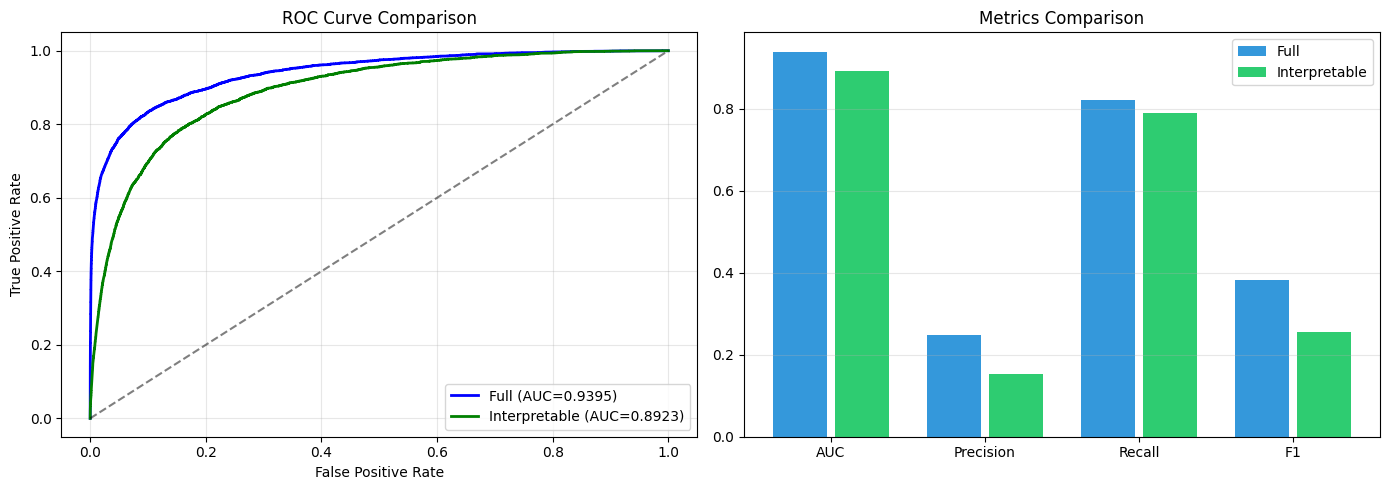

In [12]:
# ROC Curves
fpr_full, tpr_full, _ = roc_curve(y_val, y_full_val_proba)
fpr_interp, tpr_interp, _ = roc_curve(y_val, y_interp_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr_full, tpr_full, 'b-', lw=2, label=f'Full (AUC={metrics_full["val_auc"]:.4f})')
ax1.plot(fpr_interp, tpr_interp, 'g-', lw=2, label=f'Interpretable (AUC={metrics_interp["val_auc"]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Metrics bar chart
ax2 = axes[1]
metrics_names = ['AUC', 'Precision', 'Recall', 'F1']
full_vals = [metrics_full['val_auc'], metrics_full['precision'], metrics_full['recall'], metrics_full['f1']]
interp_vals = [metrics_interp['val_auc'], metrics_interp['precision'], metrics_interp['recall'], metrics_interp['f1']]

x = np.arange(len(metrics_names))
ax2.bar(x - 0.2, full_vals, 0.35, label='Full', color='#3498db')
ax2.bar(x + 0.2, interp_vals, 0.35, label='Interpretable', color='#2ecc71')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.set_title('Metrics Comparison')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Confusion Matrix ve Hata Analizi

Fraud detection'da hata türlerinin maliyeti eşit değil. Kaçan fraud (False Negative) doğrudan finansal kayıp ve güven erozyonu demek. Yanlış alarm (False Positive) ise operasyonel maliyet ve kötü müşteri deneyimi.

Rakamlarla konuşalım: Full model 109 daha fazla fraud yakalıyor. Ortalama fraud tutarı 500 dolar varsayarsak, bu yıllık 54,500 dolar tasarruf demek. Ama karşılığında 7,490 daha fazla yanlış alarm veriyor. Manuel review maliyeti işlem başına 2 dolar kabul edersek, 14,980 dolar ekstra maliyet. Net fayda yıllık yaklaşık 40,000 dolar Full model lehine.

Ama bu hesap threshold'a göre değişir. Şu an default 0.5 threshold kullanıyoruz. ModelEvaluation notebook'unda farklı threshold değerleriyle bu dengeyi optimize edeceğiz. Belki Interpretable model farklı bir threshold'da daha iyi sonuç verir.

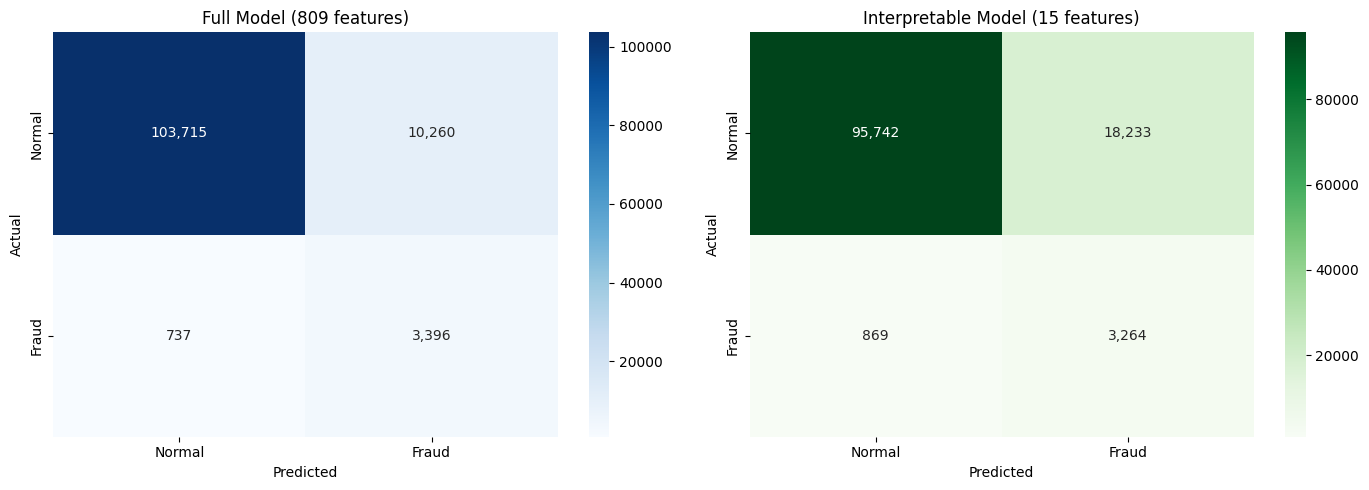


Metric                            Full   Interpretable       Diff
--------------------------------------------------------------
Fraud Caught (TP)                3,396           3,264       +132
Fraud Missed (FN)                  737             869       -132
False Alarms (FP)               10,260          18,233     -7,973


In [13]:
# Confusion matrices
cm_full = confusion_matrix(y_val, y_full_val_pred)
cm_interp = confusion_matrix(y_val, y_interp_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full model
sns.heatmap(cm_full, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title(f'Full Model ({X_full.shape[1]} features)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Interpretable model
sns.heatmap(cm_interp, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title(f'Interpretable Model ({X_interpretable.shape[1]} features)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Key metrics summary
tn_f, fp_f, fn_f, tp_f = cm_full.ravel()
tn_i, fp_i, fn_i, tp_i = cm_interp.ravel()

print(f"\n{'Metric':<25} {'Full':>12} {'Interpretable':>15} {'Diff':>10}")
print("-" * 62)
print(f"{'Fraud Caught (TP)':<25} {tp_f:>12,} {tp_i:>15,} {tp_f-tp_i:>+10,}")
print(f"{'Fraud Missed (FN)':<25} {fn_f:>12,} {fn_i:>15,} {fn_f-fn_i:>+10,}")
print(f"{'False Alarms (FP)':<25} {fp_f:>12,} {fp_i:>15,} {fp_f-fp_i:>+10,}")

## 9. Feature Importance

Feature importance grafikleri iki modelin nasıl "düşündüğünü" gösteriyor.

Full model'de V özellikleri (Vesta'nın mühendislik yaptığı black-box skorlar) baskın konumda. V258, V201, V294 gibi isimler bize bir şey söylemiyor ama model için çok değerli. Bu özelliklerin ne anlama geldiğini bilmiyoruz, bu da açıklanabilirlik sorununu net gösteriyor.

Interpretable model'de ise tablo çok farklı. TransactionAmt (işlem tutarı) açık ara en güçlü sinyal. Bu mantıklı çünkü EDA'da da gördük: mikro işlemler ve yüksek tutarlı işlemler farklı risk profilleri taşıyor. Card özellikleri (card1-card6) ikinci sırada, kart profili fraud tespitinde kritik. Adres özellikleri (addr1, addr2) coğrafi tutarsızlıkları yakalıyor. D1 (son işlemden geçen gün sayısı) temporal pattern için değerli.

İş açısından bu ne demek? Yüksek tutarlı işlemlere ekstra doğrulama, yeni kartlara dikkat, adres uyumsuzluklarına flag, hızlı ardışık işlemlere şüphe. Bunların hepsini bir analist anlayabilir ve aksiyon alabilir.

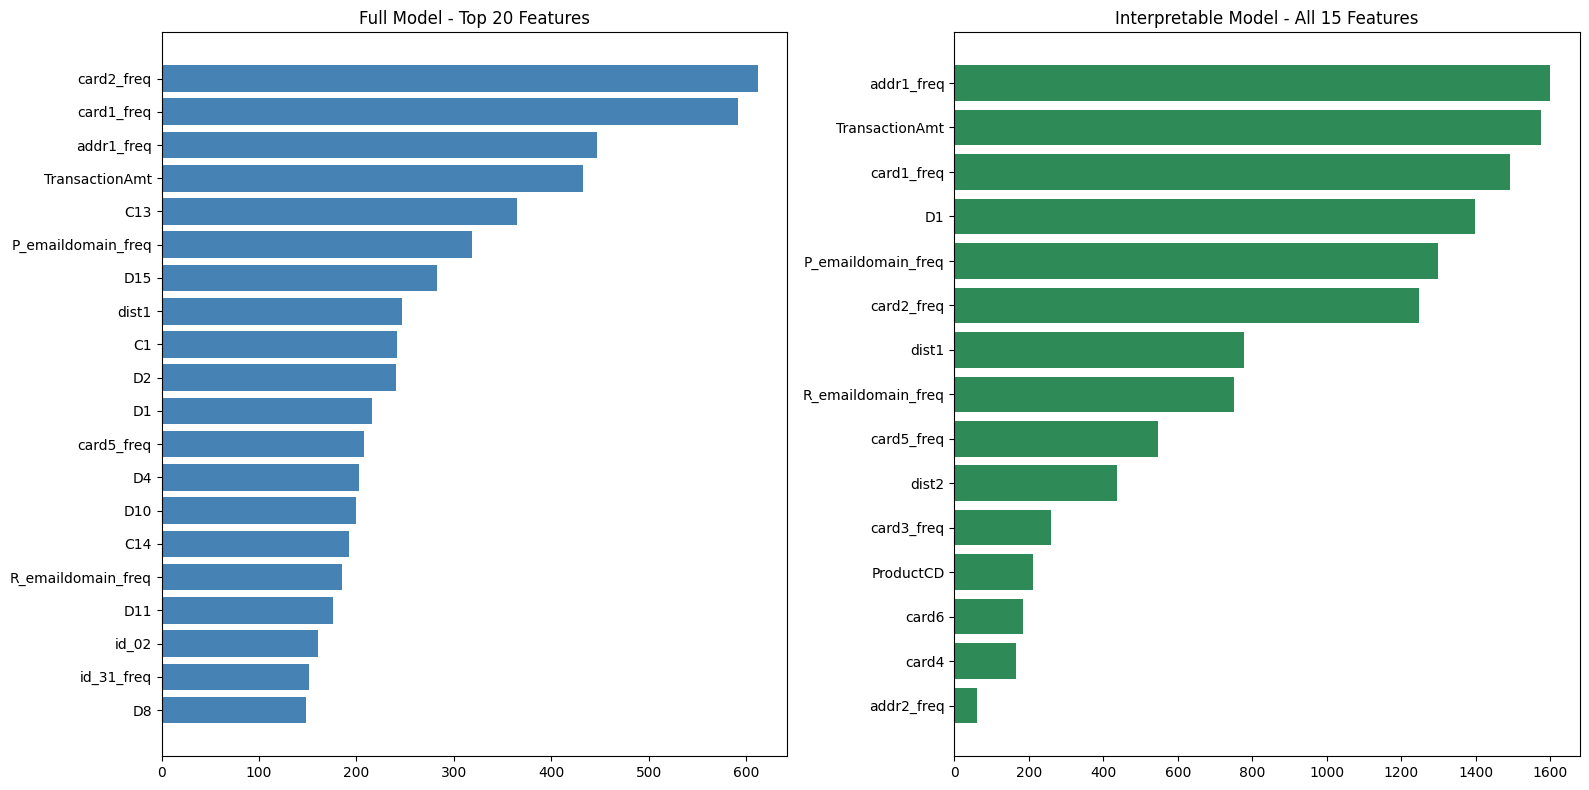

In [14]:
# Feature importance
fi_full = pd.DataFrame({
    'feature': X_full.columns,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=False)

fi_interp = pd.DataFrame({
    'feature': X_interpretable.columns,
    'importance': model_interp.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Full model top 20
top20 = fi_full.head(20)
axes[0].barh(range(20), top20['importance'], color='steelblue')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_title(f'Full Model - Top 20 Features')

# Interpretable model all features
axes[1].barh(range(len(fi_interp)), fi_interp['importance'], color='seagreen')
axes[1].set_yticks(range(len(fi_interp)))
axes[1].set_yticklabels(fi_interp['feature'])
axes[1].invert_yaxis()
axes[1].set_title(f'Interpretable Model - All {len(fi_interp)} Features')

plt.tight_layout()
plt.show()

## 10. Model Kaydetme ve Sonuç

### Kaydedilen Modeller

İki model kaydedildi: `model_full_features.pkl` maksimum performans için, `model_interpretable.pkl` açıklanabilirlik için. Her ikisi de  feature listesiyle birlikte saklanıyor.

### Ne Zaman Hangisi?

Real-time fraud blocking için Full model tercih edilmeli. Milisaniye kararlar gerektiren otomatik sistemlerde her yüzde önemli. Manuel review kuyruğu için Interpretable model daha uygun. Analist ekranında "işlem tutarı yüksek, yeni kart, adres farklı" gibi açıklamalar gösterilebilir. Regulatory audit'lerde de Interpretable model şart çünkü "algoritma öyle dedi" cevabı kabul görmüyor.

### Bu Notebook'tan Çıkarımlar

Yüzde 98 feature azaltımına rağmen rekabetçi performans elde ettik. Bu, feature engineering ile kapatılabilecek bir boşluk olduğunu gösteriyor. Basit ve anlaşılır özellikler tek başına AUC 0.90 sağlıyor, bu küçümsenecek bir sonuç değil.

### Sonraki Adımlar

FeatureEngineering notebook'unda interpretable model için yeni özellikler türetilecek. Amaç: V features'a ihtiyaç duymadan AUC'yi 0.92-0.93 seviyesine çıkarmak. ModelOptimization'da hyperparameter tuning ile her iki modelin performansı artırılacak. ModelEvaluation'da threshold optimization ve detaylı cost-benefit analizi yapılacak.

In [15]:
# Save models
os.makedirs('../../models', exist_ok=True)

joblib.dump({
    'model': model_full,
    'features': X_full.columns.tolist(),
    'metrics': metrics_full
}, '../../models/model_full_features.pkl')

joblib.dump({
    'model': model_interp,
    'features': X_interpretable.columns.tolist(),
    'metrics': metrics_interp
}, '../../models/model_interpretable.pkl')

print("Models saved:")
print(f"  - model_full_features.pkl ({X_full.shape[1]} features, AUC={metrics_full['val_auc']:.4f})")
print(f"  - model_interpretable.pkl ({X_interpretable.shape[1]} features, AUC={metrics_interp['val_auc']:.4f})")

Models saved:
  - model_full_features.pkl (809 features, AUC=0.9395)
  - model_interpretable.pkl (15 features, AUC=0.8923)
